:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`adversarial_examples_metamer.ipynb`**!

Run it in your browser: **{binder}`adversarial_examples_metamer.ipynb`**!

:::

(adversarial-examples-metamer)=
# Synthesize adversarial examples using Metamer

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

In this notebook we demonstrate how we can use the {class}`~plenoptic.Metamer` class to synthesize adversarial examples. Adversarial examples are images with subtle, imperceptible perturbations designed to deceive a Deep Neural Networks into making an incorrect classification ({cite:alp}`Szegedy2013`, {cite:alp}`goodfellow_explaining_2015`). In a non-strict sense, an adversarial example is a metamer of the new (misclassified) class because the model has the same classification behaviour for the adversarial image and other images in the class. On this basis, we can use {class}`~plenoptic.Metamer` to generate adversarial examples by matching the model output representation between the synthesized image and another image in that class. For an in-depth dive of creating metamers of Deep Neural Networks, read [](feather2023-resnet50) and [](deep_nets).

See [](adversarial-examples-mad) for an alternate approach to synthesizing adversarial examples using {class}`~plenoptic.MADCompetition`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from myst_nb import glue

import plenoptic as po

# this notebook uses torchvision, which is an optional dependency. if this import fails,
# install torchvision in your plenoptic environment and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# set seed for reproducibility
po.set_seed(4)
# To guarantee reproducibility for this example on the GPU, we must tell torch to use
# deterministic algorithms -- the default behavior for convolution is non-deterministic.
# Note this will make things slower! See "Reproducibility and Compatibility" in the docs
# for more details.
torch.use_deterministic_algorithms(True)

## Prepare model and images for synthesis

In the following block, we create a {class}`~plenoptic.models.DeepNetFeatures` model matching the output of final layer `"fc"` of a classic image recognition network, [ResNet50](https://en.wikipedia.org/wiki/Residual_neural_network), trained to classify images into one of [1000 categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/).. After creating the model, we then prepare the original image and an image of a different class whose represetnation we try to match. Finally, we ensure that the model and images have the proper device and dtype, and remove the gradient from all model parameters.

To learn more about any of these steps and why we take them, read [](deep_nets).

As part of this procedure, we must choose an image whose `"fc"` representation (and thus, categorization) we would like to match. For this example let us fool the network into thinking a macaque is a cheeseburger (image taken from the Caltech256 dataset {cite:alp}`griffin_caltech_2022`).

  7%|##7                                    | 1.02k/14.4k [00:04<00:53, 253B/s]

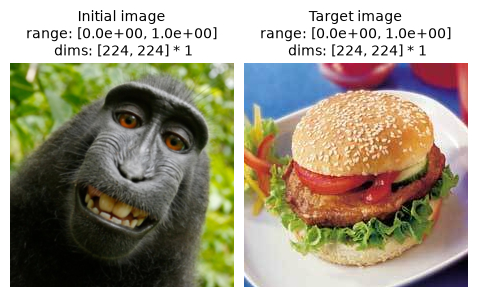

In [2]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)
deepnet.eval()
transform = weights.transforms()
norm = torchvision.transforms.Normalize(transform.mean, transform.std)
target_layer = "fc"
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)

img = po.data.macaque()
img = po.process.blur_downsample(img, 2)[..., :-59, :]
img = po.process.center_crop(img, transform.crop_size[0])

target_img = po.load_images(po.data.fetch_data("caltech256_burger.jpg"), as_gray=False)
target_img = po.process.center_crop(target_img, img.shape[-1])

po.plot.imshow([img, target_img], title=["Initial image", "Target image"], as_rgb=True)

img = img.to(DEVICE).to(torch.float64)  # convert to float64 for reproducibility
target_img = target_img.to(DEVICE).to(torch.float64)
model.to(DEVICE).to(torch.float64)
deepnet.to(DEVICE).to(torch.float64)

# remove the gradient from all model parameters
po.remove_grad(model)

## Visualizing classification of the clean image and target image
First let us extract all the [ImageNet-1K](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K) categories:

In [3]:
imagenet_categories = np.asarray(weights.meta["categories"])

Let us define three helper functions:
- `convert_to_probs` converts the activation in the final fully-connected layer to probabilities that sum to 1. It gets used in `get_category`, below.
- `get_category` accepts a single image and returns both a vector containing the category probabilities and name of the category with the highest probability.
- `get_likely_categories` accepts the category probabilities and returns all categories with probability higher than 0.01.

In [4]:
def convert_to_probs(logits):
    return torch.nn.functional.softmax(logits, dim=1).squeeze()


def get_category(image):
    category_probs = convert_to_probs(deepnet(norm(image))).detach().cpu()
    category = imagenet_categories[category_probs.argmax()]
    return category_probs, category


def get_likely_categories(category_probs):
    likely_idx = torch.where(category_probs > 0.01)[0]
    likely_idx = likely_idx[torch.argsort(category_probs[likely_idx], descending=True)]
    likely_cats = imagenet_categories[likely_idx].tolist()
    if isinstance(likely_cats, str):
        likely_cats = [likely_cats]
    return "\n".join(f"- {cat}" for cat in likely_cats)

ResNet50 is trained to classify images into one of [1000 categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). The following plot shows the classification probabilities for the original image as a stem plot. Each of the 1000 categories is represented by a line, whose y-value gives the model's probability that the image belongs to the corresponding category (the x-value is arbitrary). The title shows the label of the most likely category, and the text on the plot shows the other categories with probability higher than 0.01.

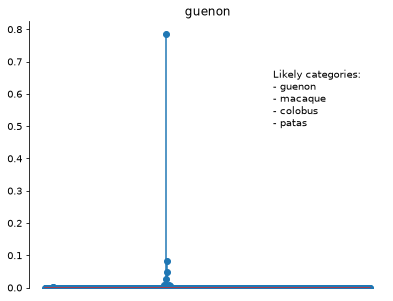

In [5]:
category_probs, category = get_category(img)
po.plot.stem_plot(category_probs, title=category)
likely_cats = get_likely_categories(category_probs)
plt.text(700, 0.5, f"Likely categories:\n{likely_cats}");

The category of our initial image, [guenon](https://en.wikipedia.org/wiki/Guenon), is an Old World monkey. Though it isn't the actual species of the monkey in question (a [Celebes crested macaque](https://en.wikipedia.org/wiki/Celebes_crested_macaque)), it's a reasonable category for it. Notice the model is highly confident in its classification, with a probability of about 0.8 and no other category exceeding a probability of 0.1. The other predicted categories are all [Old World monkeys](https://en.wikipedia.org/wiki/Old_World_monkey).

Now let us make the same plot for the target image.

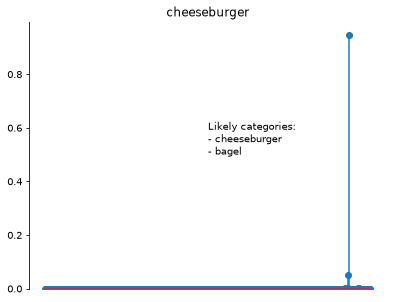

In [6]:
category_probs, category = get_category(target_img)
po.plot.stem_plot(category_probs, title=category)
likely_cats = get_likely_categories(category_probs)
plt.text(500, 0.5, f"Likely categories:\n{likely_cats}");

Putting it all together, the goal of the synthesis procedure in this notebook is to create an image that looks like our original macaque image while being classified as a cheeseburger.

## Synthesize the adversarial image

To qualify as an adversarial example, the image must satisfy two requirements ({cite:alp}`goodfellow_explaining_2015`):
1. The perturbation in image space is small.
2. The model outputs an incorrect classification with high confidence.

By starting with the original image and changing pixel values until the model output representation is matched between the synthesized and target images, the model should misclassify the synthesized image. However, we also need to constrain the synthesized image to be close to the original image in pixel space. To do this we define a penalty function that calculates the Mean Squared Error (MSE) between the original and synthesized images. In the penalty function we also add another term that penalizes pixels in the synthesized image whose values values outside $[0, 1]$.

In [7]:
def custom_penalty(image):
    # compute MSE independently per RGB channel and then average.
    epsilon_penalty = po.metric.mse(image, img).mean()
    inside_penalty = po.regularize.penalize_range(image, allowed_range=(0, 1))
    return epsilon_penalty + inside_penalty

The relative weight of the penalty in the objective function is controlled by the {attr}`~plenoptic.Metamer.penalty_lambda`. We found a value of 1000 generally worked well in our experiments.

In [8]:
met = po.Metamer(
    target_img, model, penalty_function=custom_penalty, penalty_lambda=1000
)

:::{admonition} How does {attr}`~plenoptic.Metamer.penalty_lambda` affect the adversarial image?
:class: dropdown hint

The objective function for metamer synthesis is made of two parts: the synthesis loss that measures the difference in representation between synthesized and target images, and the penalty. As {attr}`~plenoptic.Metamer.penalty_lambda` increases, the relative weight of the penalty in the objective increases. This helps ensure the synthesized and original images are close to each other in pixel space, but it makes matching the target image's representation more difficult. From our experiments, if you set {attr}`~plenoptic.Metamer.penalty_lambda` to a small value (e.g. 1), the penalty was essentially ignored and the resulting image was very distant from the original in pixel space, breaking the first requirement of an adversarial example.

If you are applying this procedure to new images or new image classification models, you will almost certainly need to experiment to find the appropriate {attr}`~plenoptic.Metamer.penalty_lambda`.

:::

We also decreased the learning rate from the default, as this resulted in better solutions in our experiments.

In [9]:
met.setup(initial_image=img, optimizer_kwargs={"lr": 0.001})

Everything has been set up, so now let's synthesize the adversarial example!

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.378155557142473e-06..0.9684456055856571].


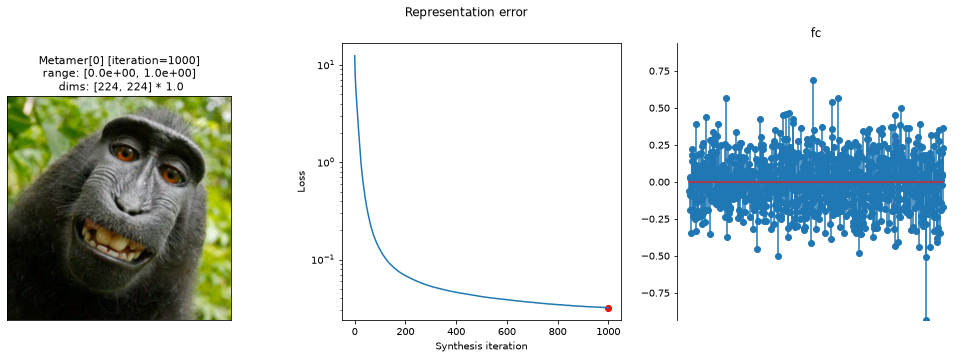

In [10]:
met.synthesize(max_iter=1000)
po.plot.synthesis_status(met);

From the middle axis in the above plot, we can see that the loss has converged. The right-most plot shows the difference in the model's `"layer4"` representation between the metamer and the target cheeseburger image; it doesn't look like there are any hotspots in the error, either spatially or in a specific channel. The synthesized metamer, shown on the left, still looks like our initial macaque image. However, we can't tell what the classification is from this plot. We will investigate that in the next section.

## Visualizing the adversarial image

First let us visualize the category probabilities of the original, target, and adversarial images using the same stem plots of categorization probability that we used above.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.378155557142473e-06..0.9684456055856571].


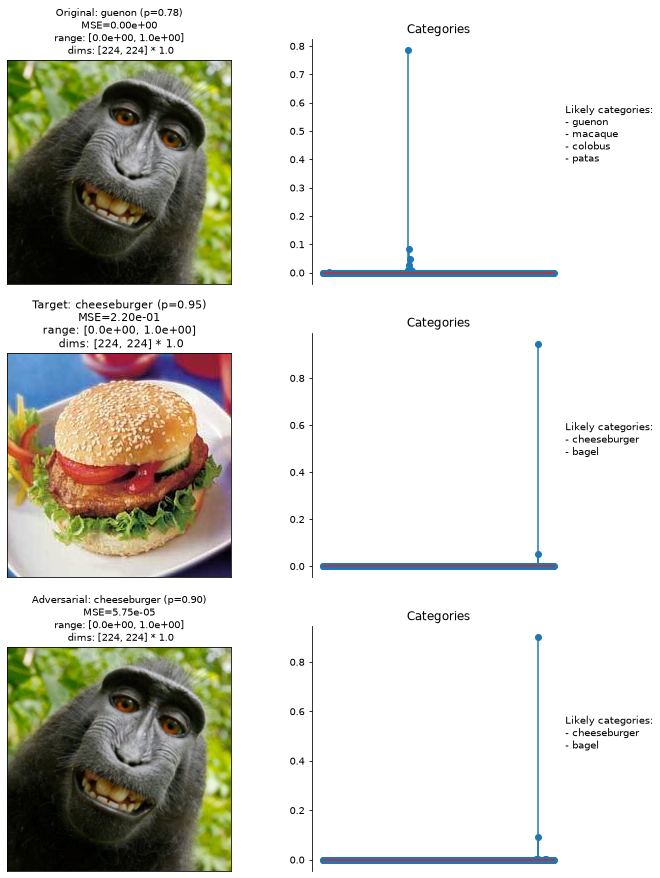

In [11]:
images = {"Original": img, "Target": target_img, "Adversarial": met.metamer}
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for i, name in enumerate(["Original", "Target", "Adversarial"]):
    category_probs, category = get_category(images[name])
    likely_cats = get_likely_categories(category_probs)
    most_likely_cat = imagenet_categories[category_probs.argmax()]
    mse_val = po.metric.mse(images["Original"], images[name]).mean().item()
    title = (
        f"{name}: {most_likely_cat} (p={category_probs.max():.2f})\nMSE={mse_val:.2e}"
    )
    po.plot.imshow(
        images[name],
        ax=axes[i, 0],
        as_rgb=True,
        title=title,
    )
    po.plot.stem_plot(category_probs, ax=axes[i, 1], ylim=False)
    axes[i, 1].set_title("Categories")
    axes[i, 0].xaxis.set_visible(False)
    axes[i, 0].yaxis.set_visible(False)
    axes[i, 1].text(
        1, 0.5, f"Likely categories:\n{likely_cats}", transform=axes[i, 1].transAxes
    )
category_probs, category = get_category(met.metamer)
glue("category_name", str(category), display=False)

In the top row, we have the original image on the left and the stem plot on the right. The middle and bottom rows correspond to the target image and the adversarial example, together with their stem plots. On top of each image, we show the MSE from the original image. The texts next to the stem plots show the most likely categories. We see the network is highly confident that the synthesized image is a {glue}`category_name`! We also see the MSE between the original and adversarial images is quite small, much smaller than that of the target image, despite both being classified as a {glue}`category_name`.

While the synthesized image is visually similar to the original image (note the low MSE with the original), let us subtract the the original image from the synthesized image to visualize the changes in pixel values.

:::{admonition} Why are we rescaling the difference image?
:class: dropdown question
Since the individual image pixel values could have either increased or decreased over synthesis, the difference image contains both positive and negative values. However, visualizing RGB images requires all pixel values to lie between 0 and 1 (see {external+matplotlib:func}`matplotlib.pyplot.imshow` for more details). Therefore, we must rescale the pixel values' to lie between 0 and 1; we additionally use {func}`~plenoptic.process.rescale` to remap the minimum and maximum to be 0 and 1, respectively, to make the structure of the difference image more visible.
:::

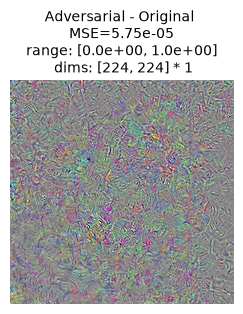

In [12]:
mse = po.metric.mse(img, met.metamer)
title = f"Adversarial - Original \nMSE={mse_val:.2e}"
diff = met.metamer - img
diff_rescaled = po.process.rescale(diff)
po.plot.imshow(diff_rescaled, as_rgb=True, title=title);

The difference between synthesized and original images has some structure but it does not look like a {glue}`category_name`, or similar. Let us also visualize the difference in each color channel (red, green, and blue) separately, to see if there's any structure hiding there.

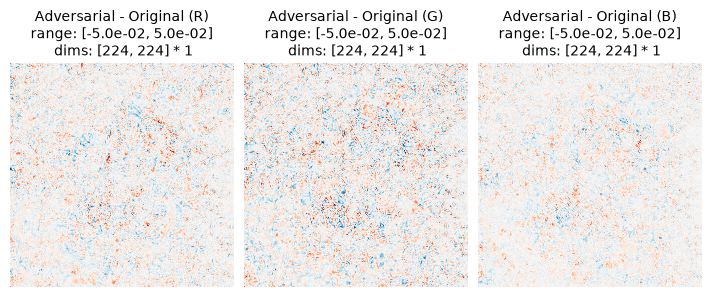

In [13]:
diff = met.metamer - img
titles = [
    "Adversarial - Original (R)",
    "Adversarial - Original (G)",
    "Adversarial - Original (B)",
]
po.plot.imshow(diff, col_wrap=3, title=titles, vrange="auto0");

We see the difference does not look like a {glue}`category_name` either in any of the individual channels or when combined. At this point we can safely conclude the synthesized image is an adversarial example of the network.

This notebook demonstrates how to generate adversarial examples using the {class}`~plenoptic.Metamer` class. We encourage you to experiment with different image classification networks, images, and hyperparameters to generate other adversarial examples yourself!